# Лабораторная работа 1
1) Найти или создать самостоятельно звуковой файл длительностью 10-15 секунд
2) Используя необходимые библиотеки провести базовый анализ сигнала:
- Вывести график сигнала в амплитудно-временной форме
- Используя преобразование Фурье отрисовать частотный спектр
- Отрисовать спектрограмму сигнала
- Вывести параметры файла: значение темпа, количество бит, частоту дискретизации и т.п.
3) Привести развернутый ответ на теоретический вопрос – что такое гармоническая и перкуссионная часть сигнала, для чего они нужны.



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
from scipy.fft import fft

In [3]:
file_path = "sound.wav"
data, sr = sf.read(file_path)

## Параметры файла

In [5]:
info = sf.info(file_path)
print("Параметры файла")
print(f"Формат: {info.format}")
print(f"Битность: {info.subtype}")
print(f"Количество каналов: {info.channels}")
print(f"Частота дискретизации: {info.samplerate} Гц")
print(f"Длительность: {info.duration:.3f} с")
print(f"Количество отсчётов: {info.frames}")
tempo, beat_frames = librosa.beat.beat_track(y=data, sr=sr, units='time')
print(f"Примерный темп: {tempo[0]:.3f} ударов в минуту")

Параметры файла
Формат: WAV
Битность: PCM_16
Количество каналов: 1
Частота дискретизации: 44100 Гц
Длительность: 12.832 с
Количество отсчётов: 565895
Примерный темп: 95.703 ударов в минуту


## Амплитудно-временная форма сигнала

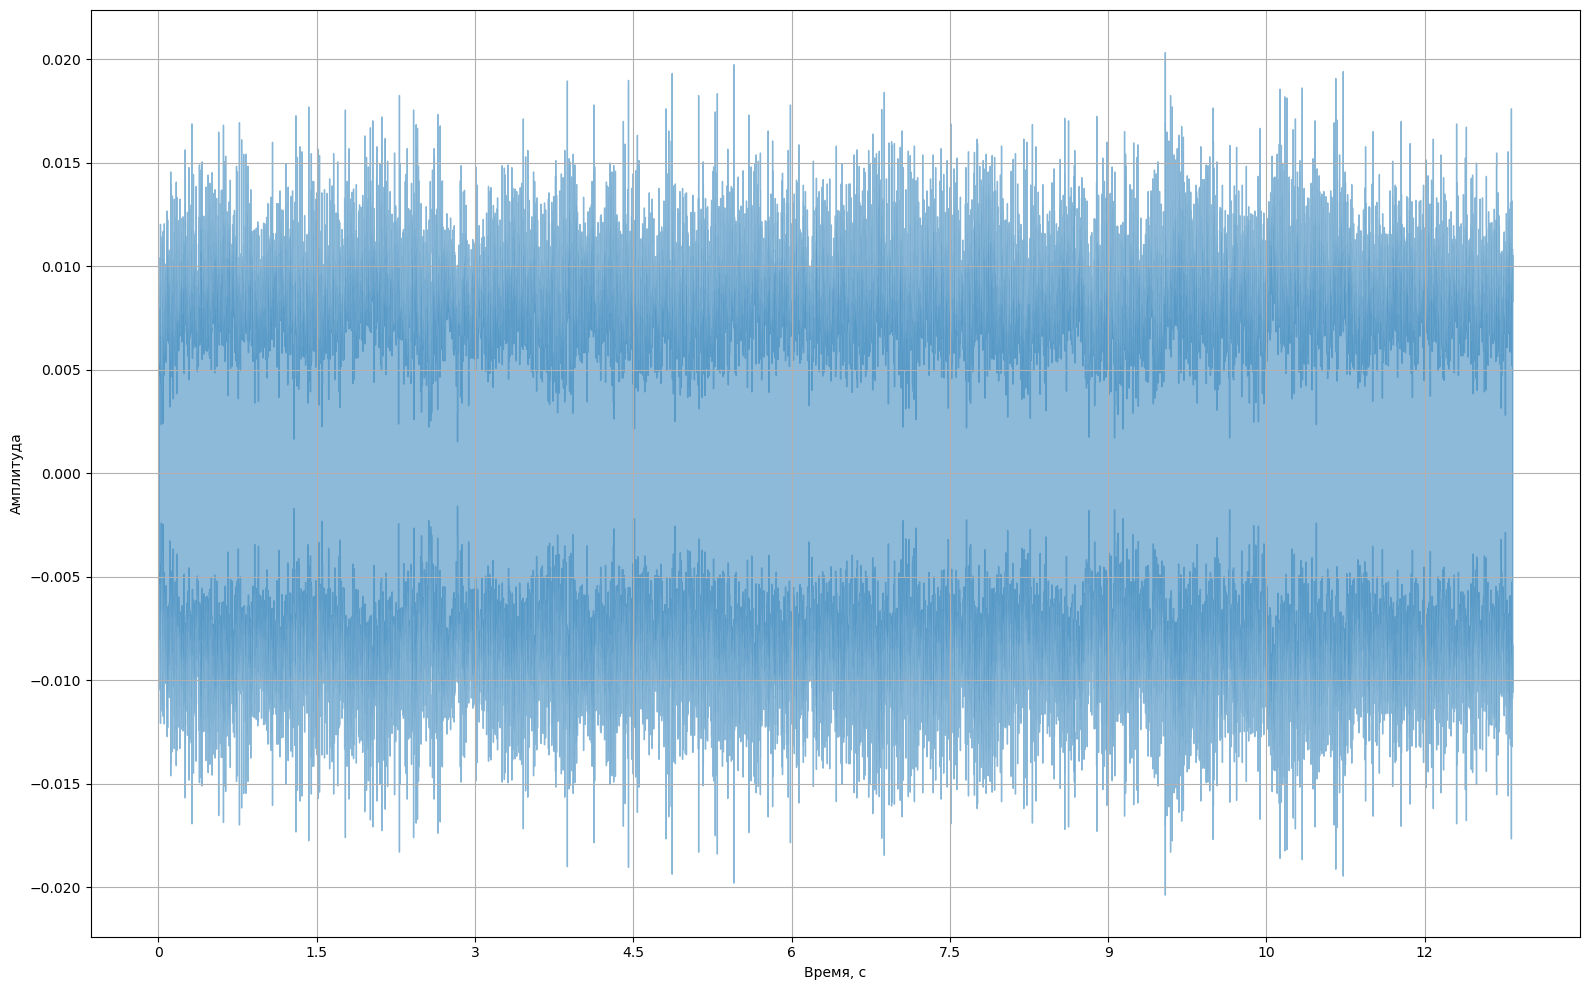

In [7]:
plt.figure(figsize=(16, 10))
librosa.display.waveshow(data, sr=sr, alpha = 0.5)
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid()
plt.tight_layout()
plt.show()

## Частотный спектр

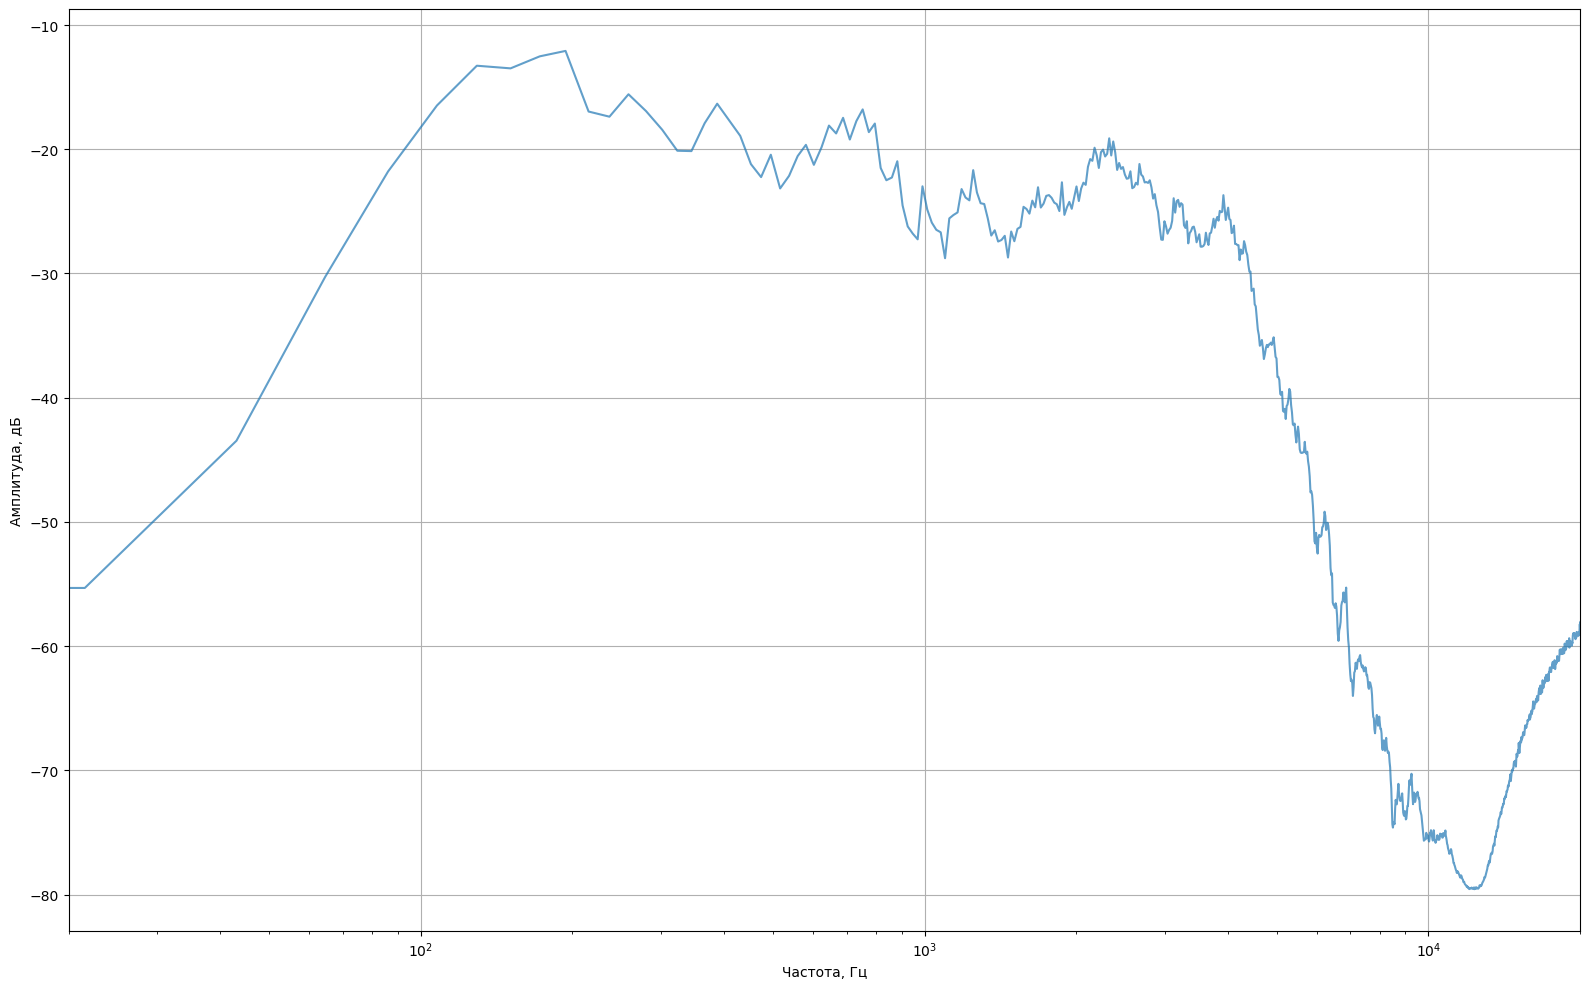

In [9]:
magnitude_spectrogram = np.abs(librosa.stft(data))
db_spectrogram = librosa.amplitude_to_db(magnitude_spectrogram, ref=np.max)
frequencies = librosa.fft_frequencies(sr=sr)

plt.figure(figsize=(16, 10))
plt.semilogx(frequencies, db_spectrogram.mean(axis=1), alpha=0.7)
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда, дБ')
plt.xlim(20, 20000)
plt.grid()
plt.tight_layout()
plt.show()

## Спектрограмма

(20.0, 20000.0)

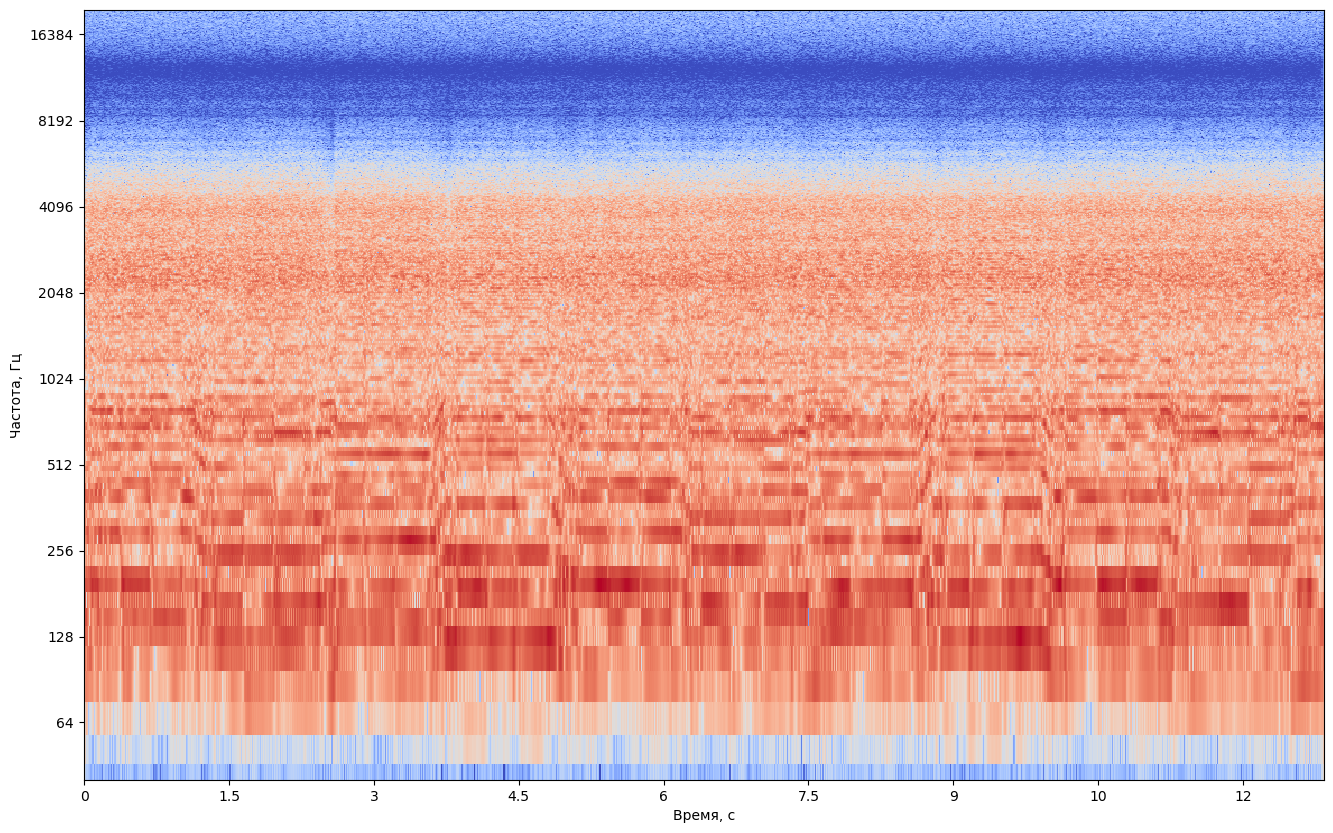

In [11]:
plt.figure(figsize=(16, 10))
librosa.display.specshow(db_spectrogram, sr=sr, x_axis='time', y_axis='log', cmap='coolwarm')
plt.xlabel('Время, с', fontsize=10)
plt.ylabel('Частота, Гц', fontsize=10)
plt.ylim(20, 20000)

## Теоретическй вопрос

### Гармоническая часть
Гармоническая часть сигнала представляет собой компоненты с периодической структурой, имеющие чётко выраженные частотные пики (основной тон и обертоны). Такие сигналы обладают определённой высотой звука и медленно меняются во времени; к ним относятся звуки музыкальных инструментов (струнные, духовые, клавишные), вокал и устойчивые тональные сигналы (гудки, сирены). На спектрограмме гармоники отображаются в виде горизонтальных или плавно изменяющихся линий, отражающих стабильность или изменение частоты во времени.

### Перкуссионная часть
Перкуссионная часть включает непериодические, шумоподобные или импульсные компоненты, не имеющие устойчивой высоты тона. Это короткие переходные процессы, возникающие при ударах, трении или резких изменениях сигнала: звуки барабанов, тарелок, шагов, хлопков, шипения, а также начальные атаки звуков. В частотной области они проявляются как широкополосные всплески энергии, во временной — как короткие импульсы, а на спектрограмме им соответствуют вертикальные полосы, охватывающие широкий диапазон частот в краткие моменты времени.